In [6]:
%matplotlib widget

import os

import xbox_proc # Structure, DateRange
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from nptdms import TdmsFile
from datetime import datetime

In [8]:
# Opening a tdms file for testing

# Load a TDMS file based on single date file

filepath = "//cernbox-drive/winspaces/x/xboxes/Xbox2_Polarix/TrendData_20190421.tdms"
tdms = TdmsFile.open(filepath)

#filepath = s.data_dir / "TrendData_20260114.tdms"
#tdms = TdmsFile.open(filepath)

group = tdms.groups()[0]

print(group.properties)
for el in group.channels():
    print(el.name)
    print(el.properties)


OrderedDict()
Timestamp
OrderedDict()
Loadside win
OrderedDict({'wf_start_time': np.datetime64('1904-01-01T00:00:00.000000'), 'wf_start_offset': 0.0, 'wf_increment': 1.0, 'wf_samples': 1, 'NI_ChannelName': 'Loadside win', 'NI_UnitDescription': 'mbar', 'unit_string': 'mbar'})
Tubeside win
OrderedDict({'wf_start_time': np.datetime64('1904-01-01T00:00:00.000000'), 'wf_start_offset': 0.0, 'wf_increment': 1.0, 'wf_samples': 1, 'NI_ChannelName': 'Tubeside win', 'NI_UnitDescription': 'mbar', 'unit_string': 'mbar'})
Collector
OrderedDict({'wf_start_time': np.datetime64('1904-01-01T00:00:00.000000'), 'wf_start_offset': 0.0, 'wf_increment': 1.0, 'wf_samples': 1, 'NI_ChannelName': 'Collector', 'NI_UnitDescription': 'mbar', 'unit_string': 'mbar'})
Gun
OrderedDict({'wf_start_time': np.datetime64('1904-01-01T00:00:00.000000'), 'wf_start_offset': 0.0, 'wf_increment': 1.0, 'wf_samples': 1, 'NI_ChannelName': 'Gun', 'NI_UnitDescription': 'mbar', 'unit_string': 'mbar'})
CC
OrderedDict({'wf_start_time': n

## Idea for analysis

Following a discussion with Lee M., the best way to proceed might be:
1. Get all the pulses which were flagged as BDs
2. Plot of these pulses:
   1. Minimum amplitude VS intensity

In [22]:
from pathlib import Path
a = []
b = []
# Replace with your folder path
folder = Path(r"//cernbox-drive/winspaces/x/xboxes/Xbox2_Polarix/")

# Find all .tdms files recursively
tdms_files = sorted(folder.rglob("*.tdms"), key=lambda p: p.name.lower())

# Print results
for file in tdms_files:
    print(f"Getting info on {file}")
    
    with TdmsFile.open(file) as tdms_file:

        matches = [
        g for g in tdms.groups()
        if g.properties.get("Log Type") == 2
        #and g.properties.get("BD_DC Down") is True
        ]

        # Print matching groups
        for group in matches:
            a.append(group.properties.get("BD_DC Down"))
            b.append(group.properties.get("BD_DC Up"))


Getting info on \\cernbox-drive\winspaces\x\xboxes\Xbox2_Polarix\EventData_20190215.tdms
Getting info on \\cernbox-drive\winspaces\x\xboxes\Xbox2_Polarix\EventData_20190218.tdms
Getting info on \\cernbox-drive\winspaces\x\xboxes\Xbox2_Polarix\EventData_20190220.tdms


[nptdms.reader WARNING] Last segment of file has less data than expected, will attempt to read to the end of the file
[nptdms.tdms_segment WARNING] Data size 146481 is not a multiple of the chunk size 236800. Will attempt to read last chunk


Getting info on \\cernbox-drive\winspaces\x\xboxes\Xbox2_Polarix\EventData_20190222.tdms
Getting info on \\cernbox-drive\winspaces\x\xboxes\Xbox2_Polarix\EventData_20190225.tdms
Getting info on \\cernbox-drive\winspaces\x\xboxes\Xbox2_Polarix\EventData_20190226.tdms
Getting info on \\cernbox-drive\winspaces\x\xboxes\Xbox2_Polarix\EventData_20190227.tdms
Getting info on \\cernbox-drive\winspaces\x\xboxes\Xbox2_Polarix\EventData_20190228.tdms
Getting info on \\cernbox-drive\winspaces\x\xboxes\Xbox2_Polarix\EventData_20190301.tdms
Getting info on \\cernbox-drive\winspaces\x\xboxes\Xbox2_Polarix\EventData_20190302.tdms
Getting info on \\cernbox-drive\winspaces\x\xboxes\Xbox2_Polarix\EventData_20190303.tdms
Getting info on \\cernbox-drive\winspaces\x\xboxes\Xbox2_Polarix\EventData_20190304.tdms
Getting info on \\cernbox-drive\winspaces\x\xboxes\Xbox2_Polarix\EventData_20190305.tdms
Getting info on \\cernbox-drive\winspaces\x\xboxes\Xbox2_Polarix\EventData_20190306.tdms
Getting info on \\cer

KeyboardInterrupt: 

In [15]:
# Triyng to get plots of BD with DC signals

start = pd.Timestamp("2019-04-20 06:00:00")
end   = pd.Timestamp("2019-04-20 18:00:00")

for i in range(3):  # 0-based
    # matches = [g for g in tdms.groups() if g.properties.get("Log Type") == 3]
    # matches = [g for g in tdms.groups() if g.properties.get("Pulse Count") == 680681282]
    matches = [g for g in tdms.groups() if (g.properties.get("Log Type") == 2) 
                                            and (g.properties.get("BD_DC Down")==True)]
    group = matches[i]
    data = {
            "pulse_count": np.array(group.properties["Pulse Count"]),
            "log_type": np.array(group.properties["Log Type"]),
            "timestamp": np.array(group.properties["Timestamp"]),
        }
    #print(data)

    # Need to build x and y axes for each channel

    data_list = ["PKI Amplitude", "PSI Amplitude", "DC Up", "DC Down", "BLM TIA"]
    
    for el in data_list:
        x=np.arange(0,group[el].properties['wf_samples'])*group[el].properties['wf_increment']
        y=xbox_proc.processing.scaling.get_scaled_channel_data(group[el])
            #PKIA and PKIB
        data.update({f"{el}_x": x, f"{el}_y": y})

    plt.rcParams.update({
        'font.size': 10,
        'axes.titlesize': 10,
        'legend.fontsize': 8,
        'lines.linewidth': 1.2})

    fig, ax = plt.subplots(2, 1, sharex=True, figsize=(5, 4), dpi = 150)

    #ax[0].plot(data['PSI Amplitude_x'], data['PSI Amplitude_y']/1e6, label='PKIA', color='tab:blue')
    ax[0].plot(data['BLM TIA_x'], data['BLM TIA_y']/1e6, label='BLM', color='tab:blue')
    
    ax[1].plot(data['DC Up_x'], data['DC Up_y'], label='DC Up', color='tab:blue')
    ax[1].plot(data['DC Down_x'], data['DC Down_y'], label='DC Down', color='tab:orange')

    #ax[2].plot(data['PERA_x'], data['PERA_y']/1e6, label='PERA', color='tab:orange')
    #ax[2].plot(data['PKRA_x'], data['PKRA_y']/1e6, label='PKRA', color='tab:red')
    #ax[2].plot(data['PSR_amp_x'], data['PSR_amp_y']/1e6, label='PSR', color='tab:green')
    #ax[2].plot(data['PKRB_x'], data['PKRB_y']/1e6, label='PKRB', color='tab:purple')

    #ax[2].plot(data['DC_DOWN_x'], data['DC_DOWN_y'], label='DC_DOWN', color='tab:orange')
    #x[2].plot(data['DC_UP_x'], data['DC_UP_y'], label='DC_UP', color='tab:blue')


    fig.supylabel("Power [MW]")
    fig.supxlabel("Time [s]")

    for axs in ax:
        axs.minorticks_on()
        axs.grid(True, which='both', linestyle='--', alpha=0.5)
        axs.legend(loc = 'upper right')
        axs.set_xlim(0, 3e-6)
        #axs.set_ylim(-0.2, 6)

    # For DC
    #ax[2].set_ylim(-500, 250)

    fig.suptitle(f"Timestamp: {data['timestamp']}") # Pulse Count: {data['pulse_count']}, Log Type: {data['log_type']}, 
    fig.tight_layout()
    #plt.savefig("../../20260108_PulseShapes.png", dpi=300)

IndexError: list index out of range

### Define structure

In [2]:
#keys = ["Timestamp", "Line 1 Pressure", "Line 2 Pressure", "DUT 1 Room Temp", "DUT 2 Room Temp", "Pulse Count 2", "Load 2 Pressure", "DUT 2 Pressure", "StructureBSurf_In Temp", "StructureBSurf_Out Temp", "StructureBWater_In Temp", "Load2 Temp", "DUT 2 Flow", "Pulse Count 1", "Load 1 Pressure", "DUT 1 Pressure", "DUT 1 Surf In Temp", "DUT 1 Surf Out Temp", "DUT 1 Water In Temp", "Load 1 RF In Temp", "DUT 1 Flow"]
keys = ["Timestamp", 'Klystron A Pressure', 'Hybrid 1 Pressure', 'Pulse Compressor 1 Pressure', 'Line 1 Pressure', "DUT 1 Pressure",'Load 1 Pressure',
        '1PKIA_ampcursor Blue mean ', '1PKIB_ampcursor Blue mean ', '1PLIA_ampcursor Blue mean ', '1PLIB_ampcursor Blue mean ', '1PSI_ampcursor grey mean ', 
        'Gauge Klystron A Pressure', 'Gauge PC 1 Pressure', 'Gauge Line 1 Pressure',  'Gauge Load 1 Pressure', 'Gauge Klystron B Pressure', 'Gauge DUT 1 Pressure',
        'Repetition rate']

s = xbox_proc.Structure(
    name="Xbox2_Polarix",
    data_dir="//cernbox-drive/winspaces/x/xboxes/Xbox2_Polarix",
    xbox=2,
    stand=None,
   
    P_ref = 42.3,  # [MW]
    G_ref = 100,  # MV/m
    t_fill=57.25e-9,
    
    BDR_ref=1.7e-6,
    PL_ref=180, # ns

    trend_keys=keys
    )

### Define data range

In [24]:
dr = xbox_proc.DateRange(20190218, 20190430)

### Extract data from tdms file to h5

In [3]:
event_df = s.extract_events(
    dr,
    out_h5="../data/event_data_Polarix.h5",
    key="event_data",
    mode="a"   # overwrite for this test (append 'a' otherwise)
)

event_df.head()

NameError: name 'dr' is not defined

### Load data from h5

In [4]:
# Load the event_data df in s object
s.load(path="../data/event_data_Polarix.h5", key="event_data")
# s.post_process()

df_event = s.df

### Example plotting

In [5]:
print(df_event.head())
print(df_event.tail())

print(df_event['BD_loc'])

   pulse_count  log_type                  timestamp  PKI_amp_total_power  \
0  706665743.0       1.0 2019-02-18 08:20:26.570506                  NaN   
1  706665743.0       1.0 2019-02-18 08:20:26.582854            -0.006572   
2  706665743.0       1.0 2019-02-18 08:20:26.592543            -0.006545   
3  706665743.0       1.0 2019-02-18 08:20:26.608343            -0.006572   
4  706665743.0       1.0 2019-02-18 08:20:26.628421            -0.006560   

   PKI_amp_length  PKI_amp_peak  PKI_amp_mean  PKI_amp_start  PSI_total_power  \
0             NaN           NaN           NaN            NaN              NaN   
1             0.0  -2502.441986           NaN            0.0         0.003906   
2             0.0  -2757.951868           NaN            0.0         0.003873   
3             0.0  -2789.683443           NaN            0.0         0.003864   
4             0.0  -2676.217804           NaN            0.0         0.003888   

      PSI_peak  ...  PEI2_peak_length  PEI2_mean_flat  P

AttributeError: PathCollection.set() got an unexpected keyword argument 'ms'

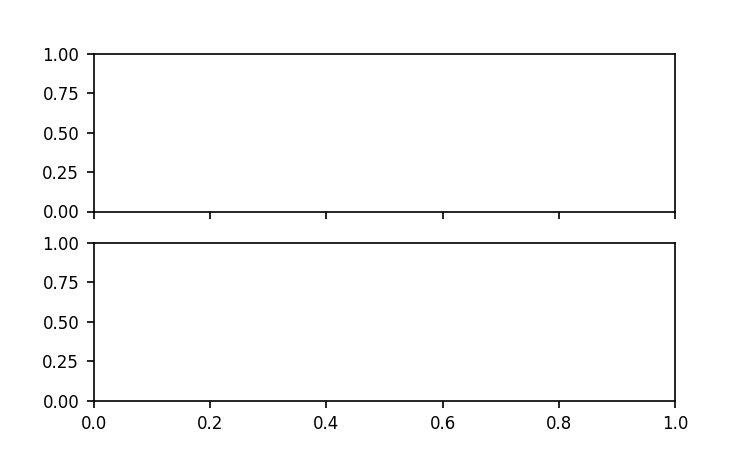

In [ ]:
plt.rcParams.update({
    'font.size': 8,
    'axes.titlesize': 10,
    'legend.fontsize': 8,
    'lines.linewidth': 1})

df_e_f = df_event.query("log_type==2")
#df_e_f = df_e_f.query("BD_loc == 2")

x = df_e_f["pulse_count"]/1e6 # M pulses

fig, ax = plt.subplots(2, 1, figsize=(5, 3), sharex=True, dpi=150)

ax[0].scatter(x, df_e_f["PSI_peak"], color = 'tab:blue', alpha=0.5)
ax[1].scatter(x, df_e_f["DC_up_peak"], color = 'tab:orange')
ax[1].scatter(x, df_e_f["DC_down_peak"], color = 'tab:red')

# Labels
ax[0].set_ylabel("PSI Peak")
ax[1].set_ylabel("DC Peaks")
ax[1].set_xlabel("x")

# Legends
ax[0].legend()
ax[1].legend()

# Dashed grid
for a in ax:
    a.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()